# Step 4 — Survival Evaluation (TensorFlow V1)

This notebook evaluates the trained multimodal valve durability model using survival-specific metrics.

It expects:

- `model_outputs_tensorflow_v1/test_survival_predictions_v1.csv`
- `model_outputs_tensorflow_v1/training_history_v1.csv`
- `synthetic_generator_outputs_v2/synthetic_multimodal_patient_year_v2_MODEL_READY.csv`

## Metrics

We compute:

1. **Harrell C-index** — ranking/discrimination
2. **Brier score** at 2, 5 and 8 years using IPCW
3. **Integrated Brier Score (IBS)** across available horizons
4. **Calibration at 5 years**
5. **Time-dependent AUC at 5 years**
6. Training/validation loss curve
7. Example survival curves

The purpose is to evaluate the current baseline before changing the architecture.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

SEED = 42

PRED_CSV = Path("model_outputs_tensorflow_v1/test_survival_predictions_v1.csv")
HISTORY_CSV = Path("model_outputs_tensorflow_v1/training_history_v1.csv")
DATA_CSV = Path("synthetic_generator_outputs_v2/synthetic_multimodal_patient_year_v2_MODEL_READY.csv")

for p in [PRED_CSV, HISTORY_CSV, DATA_CSV]:
    if not p.exists():
        print("Missing:", p.resolve())

pred = pd.read_csv(PRED_CSV)
history = pd.read_csv(HISTORY_CSV)
df = pd.read_csv(DATA_CSV)

print("Predictions:", pred.shape)
print("History:", history.shape)
print("Reference model-ready:", df.shape)

display(pred.head())


Predictions: (150, 23)
History: (21, 2)
Reference model-ready: (7169, 67)


,Patient,duration_months,event,hazard_12m,S_12m,hazard_24m,S_24m,hazard_36m,S_36m,hazard_48m,...,hazard_72m,S_72m,hazard_84m,S_84m,hazard_96m,S_96m,hazard_108m,S_108m,hazard_120m,S_120m
0,SYN_00003,52.101074,1,2.310457e-02,0.976896,5.364168e-02,0.924493,0.095960,0.835779,0.211022,...,0.307238,0.255153,0.300122,0.178576,0.461597,0.096146,0.296180,0.067669,0.263886,0.049812
1,SYN_00004,87.563538,0,1.237638e-02,0.987624,2.197622e-02,0.965920,0.057585,0.910297,0.079391,...,0.248670,0.467915,0.269695,0.341721,0.415783,0.199639,0.273602,0.145018,0.230970,0.111523
2,SYN_00006,61.732357,0,1.174882e-05,0.999988,4.833651e-05,0.999940,0.000740,0.999200,0.000704,...,0.026115,0.966367,0.057653,0.910653,0.075991,0.841452,0.091490,0.764467,0.034435,0.738143
3,SYN_00008,97.662140,0,1.664225e-07,1.000000,3.531143e-07,1.000000,0.000044,0.999955,0.000011,...,0.004396,0.995200,0.021225,0.974076,0.024373,0.950335,0.037510,0.914688,0.006387,0.908846
4,SYN_00031,62.390759,0,4.016631e-04,0.999598,5.500251e-04,0.999049,0.003777,0.995276,0.017142,...,0.094972,0.844636,0.084749,0.773054,0.218501,0.604141,0.159807,0.507595,0.057446,0.478436


## 1. Training vs validation loss

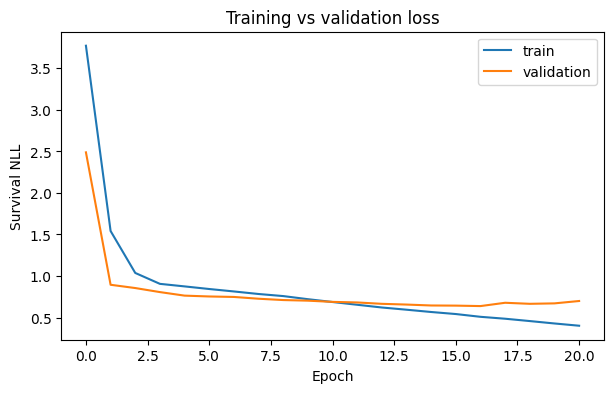

Best epoch: 17
Best validation loss: 0.6378


In [2]:
plt.figure(figsize=(7,4))
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Survival NLL")
plt.title("Training vs validation loss")
plt.legend()
plt.show()

best_epoch = int(history["val_loss"].idxmin() + 1)
best_val = float(history["val_loss"].min())

print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val, 4))


## 2. Harrell C-index

For this prototype we use **5-year predicted risk**:

`risk_5y = 1 - S(60 months)`

A comparable pair is counted when one patient has an observed event before the other patient's observed/censoring time.


In [3]:
def harrell_c_index(duration, event, risk):
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)
    risk = np.asarray(risk, dtype=float)

    concordant = 0.0
    comparable = 0.0

    n = len(duration)

    for i in range(n):
        for j in range(i + 1, n):
            # i has an observed event before j's observed time
            if event[i] == 1 and duration[i] < duration[j]:
                comparable += 1
                if risk[i] > risk[j]:
                    concordant += 1
                elif risk[i] == risk[j]:
                    concordant += 0.5

            # j has an observed event before i's observed time
            elif event[j] == 1 and duration[j] < duration[i]:
                comparable += 1
                if risk[j] > risk[i]:
                    concordant += 1
                elif risk[j] == risk[i]:
                    concordant += 0.5

    return concordant / comparable if comparable > 0 else np.nan


pred["risk_5y"] = 1.0 - pred["S_60m"]

c_index = harrell_c_index(
    pred["duration_months"],
    pred["event"],
    pred["risk_5y"],
)

print("Harrell C-index:", round(c_index, 4))


Harrell C-index: 0.8799


## 3. Reconstruct training split for censoring weights

For IPCW Brier score, censoring weights should be estimated from a separate reference population.

We reconstruct the original patient-level split with the same seed and estimate the censoring distribution from **training patients**.


In [4]:
patient_table = (
    df[["Patient", "event", "duration_months"]]
    .drop_duplicates("Patient")
    .reset_index(drop=True)
)

g1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED,
)

tr_idx, tmp_idx = next(
    g1.split(patient_table, groups=patient_table["Patient"])
)

train_patients = patient_table.iloc[tr_idx].copy()

print("Training patients used for censoring KM:", len(train_patients))


Training patients used for censoring KM: 700


## 4. Kaplan-Meier helper functions

We use Kaplan-Meier both for:

- censoring survival `G(t)` in IPCW Brier score
- observed event-free survival in calibration groups


In [5]:
def km_survival_function(times, events):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)

    unique_event_times = np.sort(np.unique(times[events == 1]))

    surv = 1.0
    out_times = [0.0]
    out_surv = [1.0]

    for t in unique_event_times:
        at_risk = np.sum(times >= t)
        d = np.sum((times == t) & (events == 1))

        if at_risk > 0:
            surv *= (1.0 - d / at_risk)

        out_times.append(float(t))
        out_surv.append(float(surv))

    return np.array(out_times), np.array(out_surv)


def km_value_at(t, km_times, km_surv, left_limit=False):
    t = float(t)

    if left_limit:
        idx = np.where(km_times < t)[0]
    else:
        idx = np.where(km_times <= t)[0]

    if len(idx) == 0:
        return 1.0

    return float(km_surv[idx[-1]])


## 5. IPCW Brier score

At horizon `t`, Brier score measures squared error between:

- predicted survival probability `S(t)`
- observed survival status at `t`

Censoring is handled with **inverse probability of censoring weights (IPCW)**.

Lower is better.


In [6]:
# Censoring process:
# event=1 in censoring KM means the patient was censored.
train_censor_event = 1 - train_patients["event"].to_numpy(dtype=int)

g_times, g_surv = km_survival_function(
    train_patients["duration_months"].to_numpy(),
    train_censor_event,
)


def ipcw_brier_score(test_df, horizon_months, survival_col):
    t = float(horizon_months)

    durations = test_df["duration_months"].to_numpy(dtype=float)
    events = test_df["event"].to_numpy(dtype=int)
    pred_surv = test_df[survival_col].to_numpy(dtype=float)

    scores = []
    weights = []

    for T, E, S_hat in zip(durations, events, pred_surv):
        # Event before or at t:
        if E == 1 and T <= t:
            G_Tminus = max(km_value_at(T, g_times, g_surv, left_limit=True), 1e-6)
            w = 1.0 / G_Tminus
            y = 0.0

        # Known to have survived beyond t:
        elif T > t:
            G_t = max(km_value_at(t, g_times, g_surv, left_limit=False), 1e-6)
            w = 1.0 / G_t
            y = 1.0

        # Censored before or at t: contributes zero weight
        else:
            w = 0.0
            y = 0.0

        scores.append(w * (y - S_hat) ** 2)
        weights.append(w)

    # Standard IPCW Brier convention averages over all subjects
    return float(np.sum(scores) / len(test_df))


brier_results = {}

for months, col in [
    (24, "S_24m"),
    (60, "S_60m"),
    (96, "S_96m"),
]:
    score = ipcw_brier_score(pred, months, col)
    brier_results[months] = score
    print(f"Brier @{months//12}y:", round(score, 4))


Brier @2y: 0.0008
Brier @5y: 0.038
Brier @8y: 0.1127


## 6. Integrated Brier Score (approximate)

In [7]:
horizons = [12,24,36,48,60,72,84,96,108,120]
available = []

for m in horizons:
    col = f"S_{m}m"
    if col in pred.columns:
        available.append((m, ipcw_brier_score(pred, m, col)))

ibs_df = pd.DataFrame(available, columns=["months","brier"])

ibs = np.trapz(
    ibs_df["brier"].to_numpy(),
    ibs_df["months"].to_numpy(),
) / (
    ibs_df["months"].iloc[-1] - ibs_df["months"].iloc[0]
)

print("Approximate Integrated Brier Score:", round(float(ibs), 4))
display(ibs_df)


Approximate Integrated Brier Score: 0.0529


,months,brier
0,12,0.000085
1,24,0.000850
2,36,0.019275
3,48,0.025463
4,60,0.038013
5,72,0.060826
6,84,0.068235
7,96,0.112746
8,108,0.109158
9,120,0.083280


## 7. 5-year time-dependent AUC

For a simple cumulative/dynamic AUC at 5 years:

- **cases** = observed event by 5 years
- **controls** = known event-free beyond 5 years
- patients censored before 5 years are excluded because their true 5-year status is unknown

Higher is better.


In [8]:
H = 60.0

known = (
    ((pred["event"] == 1) & (pred["duration_months"] <= H))
    |
    (pred["duration_months"] > H)
)

auc_df = pred.loc[known].copy()

auc_df["event_by_5y"] = (
    (auc_df["event"] == 1)
    & (auc_df["duration_months"] <= H)
).astype(int)

auc_5y = roc_auc_score(
    auc_df["event_by_5y"],
    auc_df["risk_5y"],
)

print("Known 5y status patients:", len(auc_df), "/", len(pred))
print("Time-dependent AUC @5y:", round(float(auc_5y), 4))


Known 5y status patients: 129 / 150
Time-dependent AUC @5y: 0.9708


## 8. Calibration at 5 years

Patients are grouped by predicted 5-year survival.

For each group we compare:

- mean predicted `S(5y)`
- Kaplan-Meier observed survival at 5 years

A well-calibrated model should lie close to the diagonal.


,group,n,predicted_survival_5y,observed_survival_5y_KM
0,"(0.3022, 0.9642]",30,0.671816,0.583333
1,"(0.9642, 0.9917]",30,0.980160,0.913534
2,"(0.9917, 0.9987]",30,0.996026,1.000000
3,"(0.9987, 0.9998]",30,0.999478,1.000000
4,"(0.9998, 1.0]",30,0.999930,1.000000


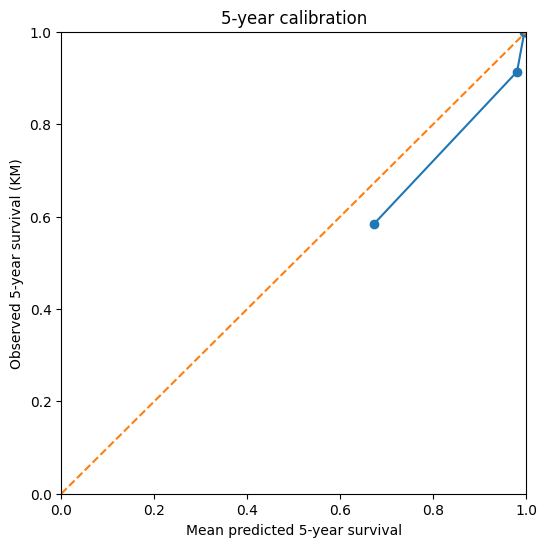

In [9]:
cal = pred.copy()

# Fewer bins are safer for a small test set.
n_bins = 5

cal["calibration_group"] = pd.qcut(
    cal["S_60m"],
    q=n_bins,
    duplicates="drop",
)

rows = []

for group, g in cal.groupby("calibration_group", observed=True):
    km_t, km_s = km_survival_function(
        g["duration_months"].to_numpy(),
        g["event"].to_numpy(dtype=int),
    )

    observed_surv_5y = km_value_at(
        60,
        km_t,
        km_s,
        left_limit=False,
    )

    rows.append({
        "group": str(group),
        "n": len(g),
        "predicted_survival_5y": float(g["S_60m"].mean()),
        "observed_survival_5y_KM": observed_surv_5y,
    })

calibration_df = pd.DataFrame(rows)

display(calibration_df)

plt.figure(figsize=(6,6))
plt.plot(
    calibration_df["predicted_survival_5y"],
    calibration_df["observed_survival_5y_KM"],
    marker="o",
)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Mean predicted 5-year survival")
plt.ylabel("Observed 5-year survival (KM)")
plt.title("5-year calibration")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()


## 9. Example survival curves

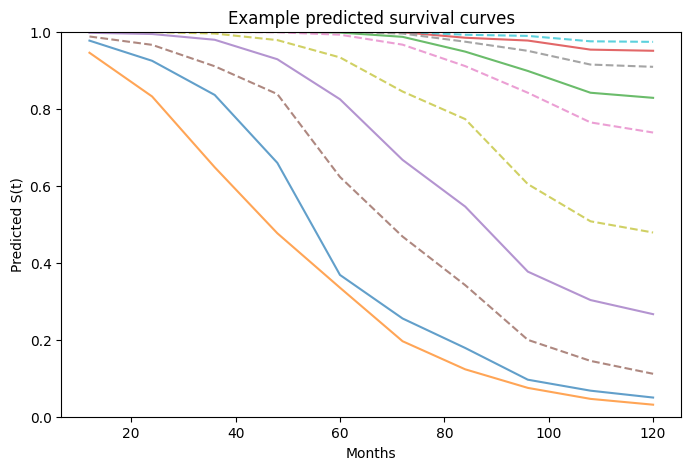

Solid: first 5 event patients
Dashed: first 5 censored patients


In [10]:
surv_cols = [
    f"S_{m}m"
    for m in horizons
    if f"S_{m}m" in pred.columns
]

x_months = [int(c.split("_")[1].replace("m","")) for c in surv_cols]

event_examples = pred[pred["event"] == 1].head(5)
censor_examples = pred[pred["event"] == 0].head(5)

plt.figure(figsize=(8,5))

for _, row in event_examples.iterrows():
    plt.plot(x_months, row[surv_cols].to_numpy(dtype=float), alpha=0.7)

for _, row in censor_examples.iterrows():
    plt.plot(x_months, row[surv_cols].to_numpy(dtype=float), linestyle="--", alpha=0.7)

plt.xlabel("Months")
plt.ylabel("Predicted S(t)")
plt.title("Example predicted survival curves")
plt.ylim(0,1)
plt.show()

print("Solid: first 5 event patients")
print("Dashed: first 5 censored patients")


## 10. Summary table

In [11]:
summary = pd.DataFrame([
    {"metric": "Harrell C-index (5y risk)", "value": c_index, "direction": "higher is better"},
    {"metric": "Brier @2y", "value": brier_results[24], "direction": "lower is better"},
    {"metric": "Brier @5y", "value": brier_results[60], "direction": "lower is better"},
    {"metric": "Brier @8y", "value": brier_results[96], "direction": "lower is better"},
    {"metric": "Integrated Brier Score", "value": ibs, "direction": "lower is better"},
    {"metric": "Time-dependent AUC @5y", "value": auc_5y, "direction": "higher is better"},
])

display(summary)

OUTDIR = Path("evaluation_outputs_v1")
OUTDIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(OUTDIR / "survival_metrics_summary.csv", index=False)
calibration_df.to_csv(OUTDIR / "calibration_5y.csv", index=False)
ibs_df.to_csv(OUTDIR / "brier_by_horizon.csv", index=False)

print("Saved evaluation tables to:", OUTDIR.resolve())


,metric,value,direction
0,Harrell C-index (5y risk),0.879913,higher is better
1,Brier @2y,0.000850,lower is better
2,Brier @5y,0.038013,lower is better
3,Brier @8y,0.112746,lower is better
4,Integrated Brier Score,0.052916,lower is better
5,Time-dependent AUC @5y,0.970807,higher is better


Saved evaluation tables to: C:\Users\User\OneDrive\Υπολογιστής\πανεπιστημιο\workstation\docathon\evaluation_outputs_v1


# How to read the results

For the current prototype, focus on three questions:

### 1. Does it rank risk correctly?
Look at **C-index** and **5-year AUC**.

### 2. Are predicted probabilities accurate?
Look at **Brier score** and **IBS**.

### 3. Can we trust the numeric probabilities?
Look at the **5-year calibration plot**.

Do not change the model architecture yet.

First inspect these metrics.  
Then the next step is **modality ablation**:

- Valve only
- Physiology only
- Medication only
- Valve + Physiology
- Full multimodal model
